# 02. Full Network Disruption Analysis

This notebook is the publication-oriented analysis framework for the Montagna network project.

It is designed to answer the full project story defined in `README.md`:

1. build one complete network by merging calls and meetings
2. describe the previous status of the network including all nodes
3. describe the current status of the network after disruption
4. prioritize interrogation among arrested actors and future arrests among surviving actors
5. produce ego-network views for the top three actors

## Notebook Roadmap

This file is intentionally structured like a final analysis notebook rather than a scratchpad.

Main sections:

- load processed metadata and raw edge lists
- normalize and merge the interaction channels
- build the full network and compute baseline metrics
- remove arrested nodes to simulate disruption
- prioritize cooperation deals among arrested actors
- prioritize future arrests among surviving actors
- generate ego-network views for the top three actors
- export tables and figures for reporting

In [81]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [82]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ROLES_PATH = PROJECT_ROOT / 'data/processed/roles.csv'
CALLS_PATH = PROJECT_ROOT / 'data/raw/Montagna_Phone_Calls_Edgelist.csv'
MEETINGS_PATH = PROJECT_ROOT / 'data/raw/Montagna_Meetings_Edgelist.csv'

PROCESSED_DIR = PROJECT_ROOT / 'data/processed'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'

roles = pd.read_csv(ROLES_PATH)
calls_raw = pd.read_csv(CALLS_PATH)
meetings_raw = pd.read_csv(MEETINGS_PATH, sep=r'\s+')

roles.head()

,Node,Role,Relationship,Request,family_role,family,arrested
0,N0,cooperating witness,NaN,NaN,cooperating witness,Unknown,0
1,N1,NaN,conversation with 0,NaN,NaN,NaN,0
2,N2,boss family ''Barcellona Pozzo di Gotto'',NaN,NaN,boss,Barcellona Pozzo di Gotto,0
3,N3,boss family ''Caltagirone'',NaN,NaN,boss,Caltagirone,0
4,N4,enterpreneur,NaN,NaN,enterpreneur,Unknown,0


## Data Audit

This section gives the initial coverage picture before any graph construction.

In [83]:
calls_nodes = set(calls_raw['Source']).union(calls_raw['Target'])
meetings_nodes = set(meetings_raw['Source']).union(meetings_raw['Target'])
role_nodes = set(roles['Node'])
network_nodes = calls_nodes.union(meetings_nodes)

pd.DataFrame(
    {
        'dataset': ['roles', 'calls', 'meetings', 'combined_interactions'],
        'rows_or_edges': [len(roles), len(calls_raw), len(meetings_raw), len(calls_raw) + len(meetings_raw)],
        'unique_nodes': [len(role_nodes), len(calls_nodes), len(meetings_nodes), len(network_nodes)],
        'nodes_with_role_metadata': [len(role_nodes), len(calls_nodes & role_nodes), len(meetings_nodes & role_nodes), len(network_nodes & role_nodes)],
    }
)

,dataset,rows_or_edges,unique_nodes,nodes_with_role_metadata
0,roles,143,143,143
1,calls,150,95,94
2,meetings,289,95,94
3,combined_interactions,439,144,142


## Helper Functions

These helpers keep the rest of the notebook compact and make it easier to iterate on the final analysis.

In [84]:
def prepare_calls_edges(calls_df):
    edges = calls_df.copy()
    edges['Weight'] = pd.to_numeric(edges['Weight'], errors='coerce').fillna(0)
    edges['channel'] = 'call'
    edges['call_weight'] = edges['Weight']
    edges['meeting_weight'] = 0
    return edges[['Source', 'Target', 'Weight', 'channel', 'call_weight', 'meeting_weight']]


def prepare_meeting_edges(meetings_df):
    edges = meetings_df.copy()
    edges['Weight'] = pd.to_numeric(edges['Weight'], errors='coerce').fillna(0)
    edges['channel'] = 'meeting'
    edges['call_weight'] = 0
    edges['meeting_weight'] = edges['Weight']

    reverse_edges = edges.rename(columns={'Source': 'Target', 'Target': 'Source'})
    directed_edges = pd.concat([edges, reverse_edges], ignore_index=True)
    return directed_edges[['Source', 'Target', 'Weight', 'channel', 'call_weight', 'meeting_weight']]


def combine_edge_tables(calls_edges, meeting_edges):
    all_edges = pd.concat([calls_edges, meeting_edges], ignore_index=True)
    combined = (
        all_edges.groupby(['Source', 'Target'], as_index=False)
        .agg(
            weight=('Weight', 'sum'),
            call_weight=('call_weight', 'sum'),
            meeting_weight=('meeting_weight', 'sum'),
            channels=('channel', lambda x: '+'.join(sorted(set(x)))),
        )
    )
    combined['edge_type'] = combined['channels'].map(lambda x: 'both' if '+' in x else x)
    return combined.sort_values(['Source', 'Target']).reset_index(drop=True)


def build_graph(edge_table, node_table):
    graph = nx.DiGraph()

    for row in node_table.to_dict('records'):
        node_id = row.pop('Node')
        graph.add_node(node_id, **row)

    for row in edge_table.to_dict('records'):
        graph.add_edge(
            row['Source'],
            row['Target'],
            weight=float(row['weight']),
            call_weight=float(row['call_weight']),
            meeting_weight=float(row['meeting_weight']),
            edge_type=row['edge_type'],
        )

    return graph


def summarize_graph(graph):
    if graph.number_of_nodes() == 0:
        return pd.Series({'nodes': 0, 'edges': 0, 'isolates': 0, 'weak_components': 0, 'largest_weak_component': 0, 'density': 0.0})

    weak_components = list(nx.weakly_connected_components(graph))
    return pd.Series(
        {
            'nodes': graph.number_of_nodes(),
            'edges': graph.number_of_edges(),
            'isolates': len(list(nx.isolates(graph))),
            'weak_components': len(weak_components),
            'largest_weak_component': max(len(component) for component in weak_components),
            'density': nx.density(graph),
        }
    )


def compute_node_metrics(graph):
    undirected_graph = graph.to_undirected()
    distance_graph = graph.copy()
    for source, target, data in distance_graph.edges(data=True):
        weight = data.get('weight', 0) or 0
        data['distance'] = 1 / weight if weight > 0 else 10**9

    try:
        pagerank = nx.pagerank(graph, weight='weight')
    except ModuleNotFoundError:
        from networkx.algorithms.link_analysis.pagerank_alg import _pagerank_python

        pagerank = _pagerank_python(graph, weight='weight')
    betweenness = nx.betweenness_centrality(distance_graph, weight='distance', normalized=True)
    in_strength = dict(graph.in_degree(weight='weight'))
    out_strength = dict(graph.out_degree(weight='weight'))
    weighted_degree = dict(undirected_graph.degree(weight='weight'))
    degree = dict(undirected_graph.degree())

    weak_components = list(nx.weakly_connected_components(graph))
    component_lookup = {}
    component_size_lookup = {}
    for component_id, component_nodes in enumerate(sorted(weak_components, key=len, reverse=True), start=1):
        for node in component_nodes:
            component_lookup[node] = component_id
            component_size_lookup[node] = len(component_nodes)

    metrics = pd.DataFrame({'Node': list(graph.nodes())})
    metrics['degree'] = metrics['Node'].map(degree).fillna(0)
    metrics['weighted_degree'] = metrics['Node'].map(weighted_degree).fillna(0.0)
    metrics['in_strength'] = metrics['Node'].map(in_strength).fillna(0.0)
    metrics['out_strength'] = metrics['Node'].map(out_strength).fillna(0.0)
    metrics['pagerank'] = metrics['Node'].map(pagerank).fillna(0.0)
    metrics['betweenness'] = metrics['Node'].map(betweenness).fillna(0.0)
    metrics['weak_component'] = metrics['Node'].map(component_lookup).fillna(-1).astype(int)
    metrics['weak_component_size'] = metrics['Node'].map(component_size_lookup).fillna(1).astype(int)
    return metrics.sort_values(['pagerank', 'weighted_degree'], ascending=False).reset_index(drop=True)


def score_family_role(role_text):
    if pd.isna(role_text):
        return 0

    role_text = str(role_text).lower()
    if 'boss' in role_text and 'deputy' not in role_text:
        return 5
    if 'co-founder' in role_text or 'deputy boss' in role_text:
        return 4
    if 'executive' in role_text:
        return 3
    if 'member' in role_text:
        return 2
    return 1


def compute_neighbor_features(graph, node_table):
    family_lookup = node_table.set_index('Node')['family'].to_dict()
    arrested_lookup = node_table.set_index('Node')['arrested'].to_dict()
    rows = []

    for node in graph.nodes():
        neighbors = set(graph.predecessors(node)).union(graph.successors(node))
        surviving_neighbors = {neighbor for neighbor in neighbors if arrested_lookup.get(neighbor, 0) == 0}

        focal_family = family_lookup.get(node, 'Unknown')
        cross_family_neighbors = {
            neighbor
            for neighbor in neighbors
            if family_lookup.get(neighbor, 'Unknown') not in {focal_family, 'Unknown'}
        }

        rows.append(
            {
                'Node': node,
                'neighbor_count': len(neighbors),
                'surviving_neighbor_count': len(surviving_neighbors),
                'cross_family_reach': len(cross_family_neighbors),
            }
        )

    return pd.DataFrame(rows)


## Build the Complete Merged Network

Meetings are converted into reciprocal directed edges so that the merged graph can be analyzed together with the directed call network.

In [85]:
calls_edges = prepare_calls_edges(calls_raw)
meeting_edges = prepare_meeting_edges(meetings_raw)
combined_edges = combine_edge_tables(calls_edges, meeting_edges)

full_graph = build_graph(combined_edges, roles)

combined_edges.head()

,Source,Target,weight,call_weight,meeting_weight,channels,edge_type
0,N0,N1,1,0,1,meeting,meeting
1,N0,N2,1,0,1,meeting,meeting
2,N1,N0,1,0,1,meeting,meeting
3,N1,N2,1,0,1,meeting,meeting
4,N10,N11,1,0,1,meeting,meeting


In [86]:
pd.DataFrame(
    {
        'table': ['calls_edges', 'meeting_edges_directed', 'combined_edges'],
        'rows': [len(calls_edges), len(meeting_edges), len(combined_edges)],
        'unique_sources': [calls_edges['Source'].nunique(), meeting_edges['Source'].nunique(), combined_edges['Source'].nunique()],
        'unique_targets': [calls_edges['Target'].nunique(), meeting_edges['Target'].nunique(), combined_edges['Target'].nunique()],
    }
)

,table,rows,unique_sources,unique_targets
0,calls_edges,150,63,65
1,meeting_edges_directed,578,95,95
2,combined_edges,583,123,123


## Previous Status of the Network

This is the baseline picture before disruption, using all nodes in the processed role table and all observed interactions from both channels.

In [87]:
full_summary = summarize_graph(full_graph)
full_metrics = compute_node_metrics(full_graph)
neighbor_features = compute_neighbor_features(full_graph, roles)

full_metrics = (
    full_metrics
    .merge(roles, on='Node', how='left')
    .merge(neighbor_features, on='Node', how='left')
)
full_metrics['role_priority_score'] = full_metrics['family_role'].apply(score_family_role)

full_summary.to_frame('value')

,value
nodes,145.000000
edges,583.000000
isolates,1.000000
weak_components,6.000000
largest_weak_component,135.000000
density,0.027921


In [88]:
full_metrics[
    ['Node', 'family_role', 'family', 'arrested', 'pagerank', 'betweenness', 'weighted_degree', 'neighbor_count', 'cross_family_reach']
].head(15)

,Node,family_role,family,arrested,pagerank,betweenness,weighted_degree,neighbor_count,cross_family_reach
0,N18,executive,Mistretta,1.0,0.054437,0.305511,85.0,40,16
1,N47,deputy boss,Batanesi,1.0,0.047491,0.238572,103.0,27,9
2,N68,executive,Batanesi,1.0,0.033258,0.124960,54.0,25,6
3,N61,executive,Mistretta,1.0,0.033255,0.095862,33.0,18,8
4,N27,executive,Batanesi,1.0,0.032027,0.077538,55.0,19,8
5,N22,Pharmacist-member,Unknown,1.0,0.030940,0.114680,45.0,17,9
6,N29,enterpreneur,Unknown,1.0,0.029000,0.211976,46.0,16,8
7,N12,member,Mistretta,1.0,0.027097,0.080198,35.0,16,6
8,N45,member,Batanesi,1.0,0.025866,0.039854,49.0,14,5
9,N89,member,Batanesi,1.0,0.024815,0.019716,46.0,11,2


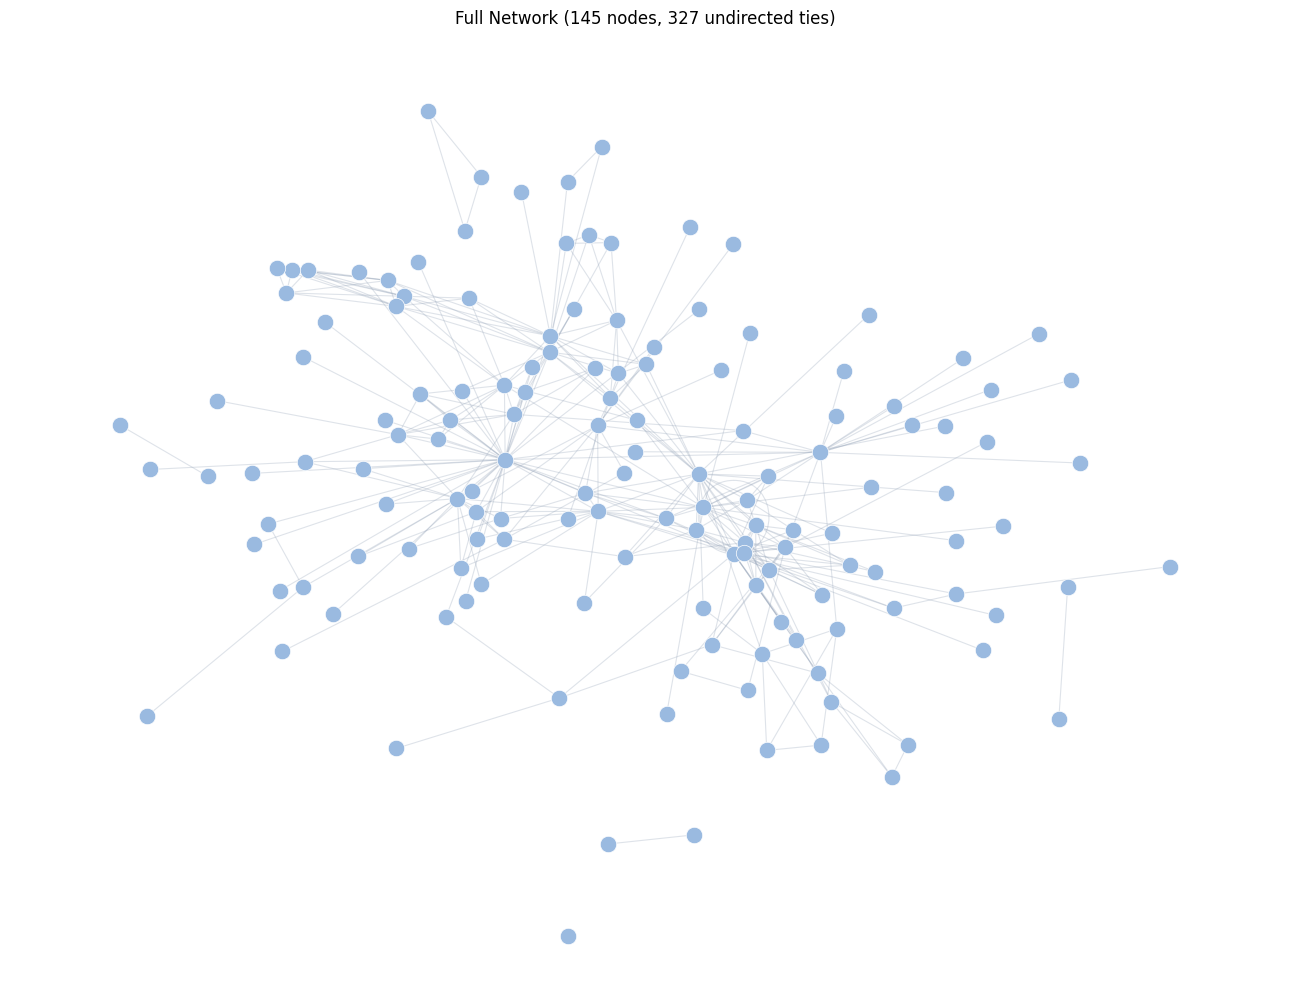

In [107]:
import numpy as np

n = full_visual_graph.number_of_nodes()

full_network_position = nx.spring_layout(
    full_visual_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

plt.figure(figsize=(13, 10))
nx.draw_networkx_edges(
    full_visual_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=0.8,
)
nx.draw_networkx_nodes(
    full_visual_graph,
    pos=full_network_position,
    node_color="#9abae0",
    node_size=140,
    edgecolors="white",
    linewidths=0.5,
)

plt.title(f"Full Network ({full_visual_graph.number_of_nodes()} nodes, {full_visual_graph.number_of_edges()} undirected ties)")
plt.axis("off")
plt.tight_layout()
plt.savefig('../reports/figures/initial_network.png')
plt.show()


## Current Status of the Network After Disruption

The disruption scenario removes actors with `arrested == 1` from the merged network and recomputes the structure on the surviving organization.

In [89]:
arrested_nodes = roles.loc[roles['arrested'] == 1, 'Node'].tolist()

disrupted_graph = full_graph.copy()
disrupted_graph.remove_nodes_from(arrested_nodes)

disrupted_summary = summarize_graph(disrupted_graph)
disrupted_metrics = compute_node_metrics(disrupted_graph).merge(roles, on='Node', how='left')

pd.concat(
    [
        full_summary.rename('full_network'),
        disrupted_summary.rename('post_disruption'),
    ],
    axis=1,
)

,full_network,post_disruption
nodes,145.000000,104.000000
edges,583.000000,122.000000
isolates,1.000000,55.000000
weak_components,6.000000,68.000000
largest_weak_component,135.000000,16.000000
density,0.027921,0.011389


In [90]:
current_status = full_metrics.merge(
    disrupted_metrics[['Node', 'pagerank', 'betweenness', 'weighted_degree', 'weak_component_size']].rename(
        columns={
            'pagerank': 'current_pagerank',
            'betweenness': 'current_betweenness',
            'weighted_degree': 'current_weighted_degree',
            'weak_component_size': 'current_component_size',
        }
    ),
    on='Node',
    how='left',
)

current_status[
    ['Node', 'arrested', 'family_role', 'pagerank', 'current_pagerank', 'weighted_degree', 'current_weighted_degree']
].head(20)

,Node,arrested,family_role,pagerank,current_pagerank,weighted_degree,current_weighted_degree
0,N18,1.0,executive,0.054437,NaN,85.0,NaN
1,N47,1.0,deputy boss,0.047491,NaN,103.0,NaN
2,N68,1.0,executive,0.033258,NaN,54.0,NaN
3,N61,1.0,executive,0.033255,NaN,33.0,NaN
4,N27,1.0,executive,0.032027,NaN,55.0,NaN
5,N22,1.0,Pharmacist-member,0.030940,NaN,45.0,NaN
6,N29,1.0,enterpreneur,0.029000,NaN,46.0,NaN
7,N12,1.0,member,0.027097,NaN,35.0,NaN
8,N45,1.0,member,0.025866,NaN,49.0,NaN
9,N89,1.0,member,0.024815,NaN,46.0,NaN


## Prioritization of Interrogation Among Arrested Actors

This ranking focuses on arrested actors only. The current scoring is a transparent starting framework combining network importance, family rank, and ability to expose surviving parts of the organization.

The weights below are intentionally easy to adjust during the final write-up.

In [91]:
arrested_priority = full_metrics.loc[full_metrics['arrested'] == 1].copy()

for column in ['pagerank', 'betweenness', 'surviving_neighbor_count', 'cross_family_reach', 'role_priority_score']:
    arrested_priority[f'{column}_pct'] = arrested_priority[column].rank(pct=True, method='average')

arrested_priority['interrogation_priority_score'] = (
    0.30 * arrested_priority['pagerank_pct']
    + 0.25 * arrested_priority['betweenness_pct']
    + 0.20 * arrested_priority['surviving_neighbor_count_pct']
    + 0.15 * arrested_priority['cross_family_reach_pct']
    + 0.10 * arrested_priority['role_priority_score_pct']
)

arrested_priority = arrested_priority.sort_values('interrogation_priority_score', ascending=False)
arrested_priority[
    ['Node', 'family_role', 'family', 'pagerank', 'betweenness', 'surviving_neighbor_count', 'cross_family_reach', 'interrogation_priority_score']
].head(15)

,Node,family_role,family,pagerank,betweenness,surviving_neighbor_count,cross_family_reach,interrogation_priority_score
0,N18,executive,Mistretta,0.054437,0.305511,23,16,0.989024
1,N47,deputy boss,Batanesi,0.047491,0.238572,10,9,0.970122
2,N68,executive,Batanesi,0.033258,0.124960,8,6,0.901829
3,N61,executive,Mistretta,0.033255,0.095862,7,8,0.886585
5,N22,Pharmacist-member,Unknown,0.030940,0.114680,8,9,0.879878
4,N27,executive,Batanesi,0.032027,0.077538,5,8,0.843902
7,N12,member,Mistretta,0.027097,0.080198,11,6,0.826220
13,N25,executive,Mistretta,0.018661,0.048691,8,7,0.796951
6,N29,enterpreneur,Unknown,0.029000,0.211976,4,8,0.795122
8,N45,member,Batanesi,0.025866,0.039854,5,5,0.746341


## Prioritization of Future Arrests Among Surviving Actors

This ranking focuses on non-arrested actors. It combines importance in the full network with prominence in the post-disruption network.

In [92]:
surviving_priority = current_status.loc[current_status['arrested'] == 0].copy()
surviving_priority['current_pagerank'] = surviving_priority['current_pagerank'].fillna(0.0)
surviving_priority['current_weighted_degree'] = surviving_priority['current_weighted_degree'].fillna(0.0)

for column in ['pagerank', 'betweenness', 'current_pagerank', 'current_weighted_degree', 'role_priority_score']:
    surviving_priority[f'{column}_pct'] = surviving_priority[column].rank(pct=True, method='average')

surviving_priority['future_arrest_priority_score'] = (
    0.25 * surviving_priority['pagerank_pct']
    + 0.20 * surviving_priority['betweenness_pct']
    + 0.25 * surviving_priority['current_pagerank_pct']
    + 0.20 * surviving_priority['current_weighted_degree_pct']
    + 0.10 * surviving_priority['role_priority_score_pct']
)

surviving_priority = surviving_priority.sort_values('future_arrest_priority_score', ascending=False)
surviving_priority[
    ['Node', 'family_role', 'family', 'pagerank', 'current_pagerank', 'betweenness', 'future_arrest_priority_score']
].head(15)

,Node,family_role,family,pagerank,current_pagerank,betweenness,future_arrest_priority_score
10,N11,boss Cosa Nostra in Messina,Unknown,0.023814,0.038438,0.033921,0.997059
38,N3,boss,Caltagirone,0.007859,0.022930,0.007456,0.929412
23,N6,NaN,NaN,0.010151,0.029054,0.016887,0.906863
22,N5,NaN,NaN,0.010151,0.029054,0.016887,0.906863
41,N79,enterpreneur,Unknown,0.007129,0.029646,0.010101,0.890196
35,N39,executive,Batanesi,0.008616,0.020209,0.023423,0.875245
37,N14,boss,Mazzaroti,0.007961,0.018665,0.005536,0.866176
25,N34,NaN,NaN,0.009494,0.029479,0.000012,0.844608
48,N40,member,Mazzaroti,0.006113,0.020209,0.002946,0.836520
26,N13,enterpreneur,Unknown,0.009128,0.020622,0.000000,0.817647


## Ego Networks for the Top Three Actors

The table below identifies the current top three actors in the full merged network. The plotting cell after it is meant to become the publication-ready ego-network figure.

In [93]:
top3_nodes = full_metrics.sort_values(['pagerank', 'weighted_degree'], ascending=False).head(3)['Node'].tolist()

ego_summary_rows = []
for node in top3_nodes:
    ego_graph = nx.ego_graph(full_graph.to_undirected(), node, radius=1)
    ego_summary_rows.append(
        {
            'Node': node,
            'family_role': roles.set_index('Node').get('family_role', pd.Series()).get(node, pd.NA),
            'family': roles.set_index('Node').get('family', pd.Series()).get(node, pd.NA),
            'ego_nodes': ego_graph.number_of_nodes(),
            'ego_edges': ego_graph.number_of_edges(),
        }
    )

pd.DataFrame(ego_summary_rows)

,Node,family_role,family,ego_nodes,ego_edges
0,N18,executive,Mistretta,41,90
1,N47,deputy boss,Batanesi,27,82
2,N68,executive,Batanesi,26,74


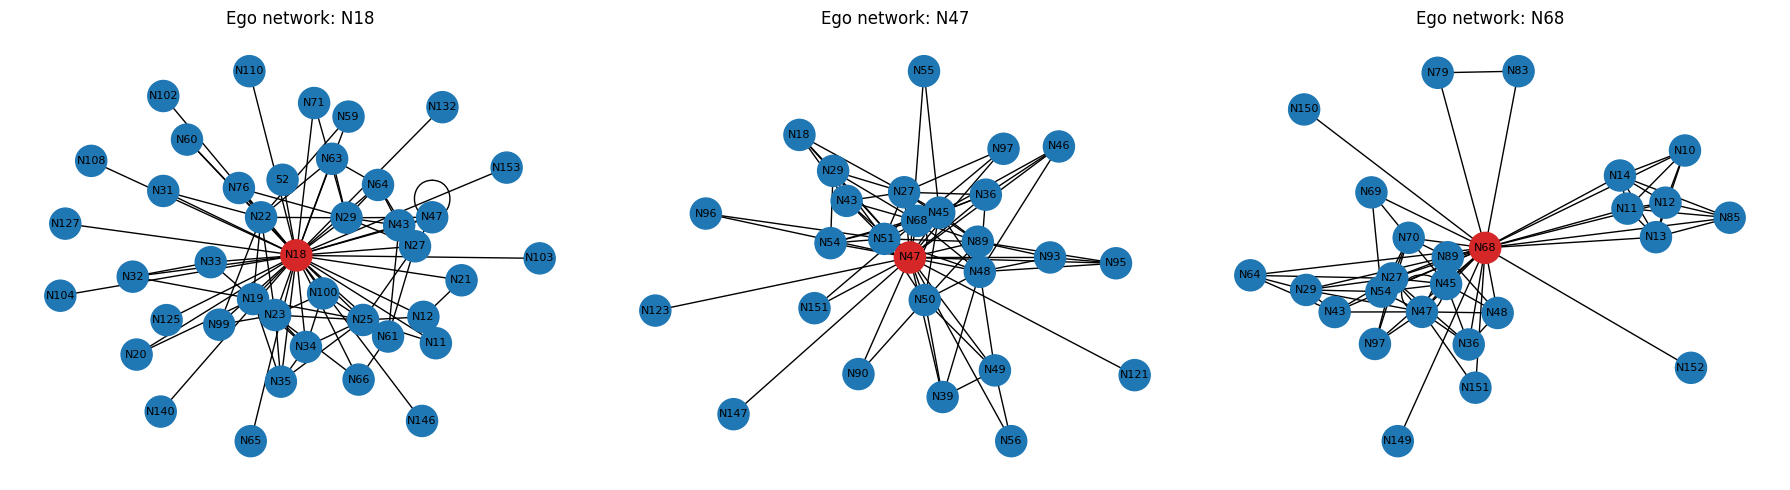

In [94]:
family_lookup = roles.set_index('Node')['family'].to_dict()
fig, axes = plt.subplots(1, len(top3_nodes), figsize=(6 * max(len(top3_nodes), 1), 5))
axes = [axes] if len(top3_nodes) == 1 else axes

for axis, node in zip(axes, top3_nodes):
    ego_graph = nx.ego_graph(full_graph.to_undirected(), node, radius=1)
    position = nx.spring_layout(ego_graph, seed=42)
    node_colors = ['tab:red' if n == node else 'tab:blue' for n in ego_graph.nodes()]
    nx.draw_networkx(ego_graph, pos=position, ax=axis, node_color=node_colors, with_labels=True, node_size=500, font_size=8)
    axis.set_title(f'Ego network: {node}')
    axis.axis('off')

plt.tight_layout()
plt.show()

# TODO: replace this starter plot with the final styled figure for publication.
# Suggested improvements: family-based colors, legend, weighted edge widths, and labels for role/rank.

## Output Tables and Figures

These exports are the bridge from notebook analysis to the final report and presentation assets.

In [95]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

planned_outputs = pd.DataFrame(
    {
        'artifact': [
            'combined_edges',
            'node_metrics_full',
            'node_metrics_disrupted',
            'interrogation_priority',
            'future_arrest_priority',
            'top3_ego_networks_figure',
        ],
        'path': [
            str(PROCESSED_DIR / 'combined_edges.csv'),
            str(PROCESSED_DIR / 'node_metrics_full.csv'),
            str(PROCESSED_DIR / 'node_metrics_disrupted.csv'),
            str(REPORTS_DIR / 'interrogation_priority.csv'),
            str(REPORTS_DIR / 'arrest_priority.csv'),
            str(FIGURES_DIR / 'top3_ego_networks.png'),
        ],
    }
)

planned_outputs

,artifact,path
0,combined_edges,/home/ivadi/projects/sicilian_mafia/data/proce...
1,node_metrics_full,/home/ivadi/projects/sicilian_mafia/data/proce...
2,node_metrics_disrupted,/home/ivadi/projects/sicilian_mafia/data/proce...
3,interrogation_priority,/home/ivadi/projects/sicilian_mafia/reports/in...
4,future_arrest_priority,/home/ivadi/projects/sicilian_mafia/reports/ar...
5,top3_ego_networks_figure,/home/ivadi/projects/sicilian_mafia/reports/fi...


In [98]:
# Uncomment these lines once the notebook results are final.
combined_edges.to_csv(PROCESSED_DIR / 'combined_edges.csv', index=False)
full_metrics.to_csv(PROCESSED_DIR / 'node_metrics_full.csv', index=False)
disrupted_metrics.to_csv(PROCESSED_DIR / 'node_metrics_disrupted.csv', index=False)
arrested_priority.to_csv(REPORTS_DIR / 'interrogation_priority.csv', index=False)
surviving_priority.to_csv(REPORTS_DIR / 'arrest_priority.csv', index=False)
# plt.savefig(FIGURES_DIR / 'top3_ego_networks.png', dpi=300, bbox_inches='tight')

## Narrative Conclusions

Use the final section to write the publication-ready interpretation.

Suggested prompts:

- What did the organization look like before disruption?
- Which families and actors dominated the full network?
- How much did arrests fragment or weaken the network?
- Which arrested actors are best positioned to reveal the remaining leadership?
- Which surviving actors should be prioritized next?